# Importação de Bibliotecas

In [ ]:
# Instalações Necessárias
!pip install pyphen
!pip install liwc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 35.4 MB/s eta 0:00:00


In [ ]:
# Processamento de Texto
import re
import pyphen

# Processamento de Linguagem Natural (PLN)
import spacy
spacy.cli.download("pt_core_news_sm")
import liwc

# Computação Numérica
import numpy as np

# Manipulação e Visualização de Dados
import pandas as pd
import matplotlib.pyplot as plt

# Aprendizado de Máquina
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Caminhos de Arquivos

In [ ]:
# Altere os caminhos conforme necessário

# Corpus SteamBR filtrado (arquivo pickle)
path_steamcorpusbr_filtrado = "df_pt.pkl"

# Dicionário Léxico LIWC (pt-br)
path_liwc = "Brazilian_Portuguese_LIWC2015_dictionary.dic"

# Dicionário de Características de Produto
path_product_features = "product_features.txt"

# Subconjuntos de Saída
path_output_dev = "symbolic_dev_df.pkl"
path_output_train = "symbolic_train_df.pkl"
path_output_test = "symbolic_test_df.pkl"

# Importação de Dataset Pré-Processado

In [ ]:
df = pd.read_pickle(path_steamcorpusbr_filtrado)

In [ ]:
df.sample(10)

,recommendationid,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,...,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,timestamp_dev_responded,developer_response,votes_log,is_pt
2272927,47581581,brazilian,"Um dos melhores RPG's que joguei em 2018, ótim...",1545012888,1545012888,True,10,0,0.64453589916229248,0,...,184,112,5704,0,5704.0,1545012618,NaN,NaN,2.397895,True
1767903,90555259,brazilian,tô a quase 3 anos jogando esse jogo e continuo...,1618798822,1618798822,True,29,16,0.774716734886169434,0,...,9,1,45105,0,34486.0,1642251938,NaN,NaN,3.401197,True
1331158,57885885,brazilian,Melhor Remake já feito da nova geração!,1574792132,1574792132,True,3,0,0.50513535737991333,0,...,1087,37,5568,0,4993.0,1637444459,NaN,NaN,1.386294,True
2610384,50800068,brazilian,"Um jogo para evoluir o seu raciocínio lógico, ...",1558695511,1558695511,True,15,1,0.688859820365905762,0,...,94,1,80110,0,58491.0,1601584995,NaN,NaN,2.772589,True
1596301,24117966,brazilian,Que jogo mais ruim,1467750286,1467750286,False,3,3,0.426745325326919556,0,...,202,80,475,0,468.0,1567085346,NaN,NaN,1.386294,True
1150421,29875898,brazilian,Pro jogo ficar completo só falta tomar sustos....,1486914063,1486914063,True,4,0,0.574534177780151367,0,...,120,12,3745,0,1289.0,1627020135,NaN,NaN,1.609438,True
1611392,67793189,brazilian,Antes tinha o recurso de jogar com os amigos G...,1587525461,1587525461,False,64,0,0.823537230491638184,0,...,30,2,599,0,599.0,1587525410,NaN,NaN,4.174387,True
2017019,61830430,brazilian,Fico me perguntando como eu só vim jogar essa ...,1578982647,1578982955,True,6,0,0.565217375755310059,0,...,424,15,5215,0,2693.0,1633083157,NaN,NaN,1.945910,True
1514673,53073378,brazilian,Prefiro Lego,1562044429,1562044429,True,3,1,0.5,0,...,271,5,143,0,111.0,1614208586,NaN,NaN,1.386294,True
450094,26962520,brazilian,"Gostaria de estar escrevendo uma análise, mas ...",1479947646,1479947759,True,4,0,0.556291401386260986,0,...,221,16,1810,0,1036.0,1497326467,NaN,NaN,1.609438,True


# Extração de Métricas

## Tokenização, número de tokens, número de frases e tamanho médio de sentença

In [ ]:
nlp = spacy.load("pt_core_news_sm", disable=["ner", "tagger", "parser"])
nlp.add_pipe("sentencizer")

def text_size(text):
  doc = nlp(text)
  tokens = [t.text for t in doc if not t.is_space]
  num_tokens = len([t for t in doc if not t.is_space])
  sentences = len(list(doc.sents))
  average_sentence_length = num_tokens / sentences
  return tokens, num_tokens, sentences, average_sentence_length

In [ ]:
df[["tokens", "token_count", "sentence_count", "average_sentence_length"]] = df["review"].apply(lambda x: pd.Series(text_size(x)))

## SMOG

In [ ]:
dic = pyphen.Pyphen(lang='pt_BR')
# Não se dá bem com palavras com água, águia
def contar_silabas(palavra):
  hifenizada = dic.inserted(palavra)
  return len(hifenizada.split('-'))

# Heurística para contar sílabas, não se dá bem com hiatos
#def contar_silabas(palavra):
#  palavra = palavra.lower()
#
#  # Remove 'u' mudo
#  palavra = re.sub(r'qu', 'q', palavra)
#  palavra = re.sub(r'gu([ei])', r'g\1', palavra)
#
#  grupos_vogais = re.findall(r'[aeiouáéíóúâêôãõàü]+', palavra)
#
#  return max(1, len(grupos_vogais))

def contar_palavras_polissilabicas(palavras):
  num_palavras_polissilabicas = 0
  for palavra in palavras:
    if contar_silabas(palavra) >= 3:
      num_palavras_polissilabicas += 1
  return num_palavras_polissilabicas

def calcular_SMOG(palavras, num_frases):
  num_palavras_polissilabicas = contar_palavras_polissilabicas(palavras)
  return 1.043 * np.cbrt(num_palavras_polissilabicas * 30 / num_frases) + 3.1291

In [ ]:
df = df.assign(
  smog_grade=lambda d: d.apply(
    lambda row: calcular_SMOG(row["tokens"], row["sentence_count"]),
    axis=1
  )
)

## Intensidade Emocional

In [ ]:
def load_liwc(filepath):
  categories = {}
  lexicon = {}
  prefixes = {}

  with open(filepath, encoding="utf-8-sig") as f:
    lines = f.readlines()

  section = 0

  for line in lines:
    line = line.strip()

    if not line:
      continue

    if line == "%":
      section += 1
      continue

    parts = line.split()

    if section == 1:
      cat_id = int(parts[0])
      cat_name = parts[1]
      categories[cat_id] = cat_name

    elif section == 2:
      word = parts[0]

      cat_names = []
      for p in parts[1:]:
        if p.isdigit():
          cat_id = int(p)
          if cat_id in categories:
            cat_names.append(categories[cat_id])
          else:
            print(f"Warning: unknown category id '{cat_id}' for word '{word}'")
        else:
          print(f"Warning: invalid category '{p}' for word '{word}'")

      if word.endswith("*"):
        prefix = word[:-1]
        prefixes[prefix] = cat_names
      else:
        lexicon[word] = cat_names

  return categories, lexicon, prefixes

In [ ]:
categories, lexicon, prefixes = load_liwc(path_liwc)

def liwc_parse(word, lexicon, prefixes, categories):
  # Correspondência com palavras inteiras
  if word in lexicon:
    return lexicon[word]

  # Correspondência com prefixos
  for prefix in prefixes:
    if word.startswith(prefix):
      return prefixes[prefix]

  return []

def liwc_word_intensity(word, lexicon, prefixes, categories):
  # Obtém a lista de categorias para uma determinada palavra
  # Retorna a polaridade com base na presença de "emoção positiva" ou "emoção negativa"

  cats = list(liwc_parse(word, lexicon, prefixes, categories))
  if not cats:
    return None

  #print(cats)
  word_int = 0

  if "posemo" in cats:
    word_int += 1
  if "negemo" in cats:
    word_int += 1

  return word_int

def liwc_review_intensity(review_tokens):
  review_int = 0
  for word in review_tokens:
    word_int = liwc_word_intensity(word, lexicon, prefixes, categories)
    if word_int is not None:
      review_int += word_int
  return review_int / len(review_tokens)

In [ ]:
df[["sent_intensity"]] = df["tokens"].apply(lambda x: pd.Series(liwc_review_intensity(x)))

## Características de Produto

In [ ]:
import unicodedata

def normalize(text):
  text = text.lower()
  text = unicodedata.normalize("NFD", text)
  text = "".join(c for c in text if unicodedata.category(c) != "Mn")
  return text

def load_features(filepath):
  with open(filepath, encoding="utf-8") as f:
      features = [line.strip() for line in f if line.strip()]

  # normalize + deduplicate
  features = list(set(normalize(f) for f in features))

  return features

import re

def count_features(review, features):
  text = normalize(review)

  count = 0

  for feature in features:
    pattern = r"\b" + re.escape(feature) + r"\b"
    if re.search(pattern, text):
      count += 1

  return count

In [ ]:
features = load_features(path_product_features)

df["feature_count"] = df["review"].apply(
    lambda x: count_features(x, features)
)
df["feature_density"] = df["feature_count"] / df["token_count"]

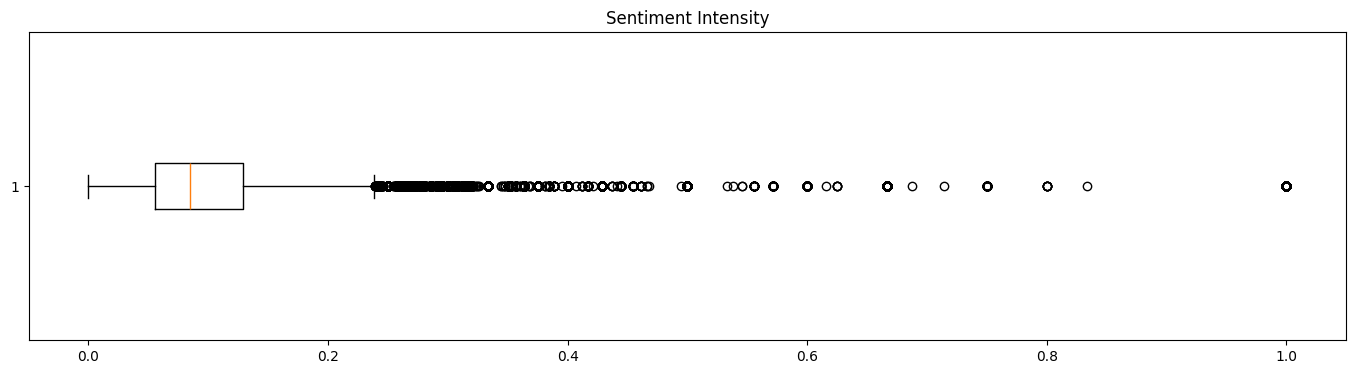

In [ ]:
plt.figure(figsize=(17, 4))
plt.boxplot(df["sent_intensity"], vert=False)
plt.title("Sentiment Intensity")
plt.show()

# Predição de Utilidade

## Divisão da Base de Dados

In [ ]:
# Treinamento (70%) and Temporário (30%):
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)

# Desenvolvimento (10%) e Teste (20%):
dev_df, test_df = train_test_split(temp_df, test_size=2/3, random_state=42)

## Terceiro Quartis dos Atributos (Subonjunto de Desenvolvimento)

In [ ]:
token_count_Q3 = dev_df["token_count"].quantile(0.75)
sentence_count_Q3 = dev_df["sentence_count"].quantile(0.75)
average_sentence_length_Q3 = dev_df["average_sentence_length"].quantile(0.75)
feature_count_Q3 = dev_df["feature_count"].quantile(0.75)
sent_intensity_Q3 = dev_df["sent_intensity"].quantile(0.75)

## Cálculo da Notas Finais

In [ ]:
def normalizar_atributos(dataset):
  dataset["average_sentence_length_norm"] = (dataset["average_sentence_length"] / average_sentence_length_Q3).clip(upper=1)
  dataset["token_count_norm"] = (dataset["token_count"] / token_count_Q3).clip(upper=1)
  dataset["sentence_count_norm"] = (dataset["sentence_count"] / sentence_count_Q3).clip(upper=1)
  dataset["sent_intensity_norm"] = (dataset["sent_intensity"] / sent_intensity_Q3).clip(upper=1)
  dataset["smog_grade_norm"] = (dataset["smog_grade"] / 12).clip(upper=1)
  dataset["feature_count_norm"] = (dataset["feature_count"] / feature_count_Q3).clip(upper=1)
  return dataset

In [ ]:
def calcular_nota_final(dataset):
  dataset["nota_final"] = (
    dataset["average_sentence_length_norm"] * 0.3 +
    dataset["token_count_norm"] * 0.1 +
    dataset["sentence_count_norm"] * 0.1 +
    dataset["sent_intensity_norm"] * 0.3 +
    dataset["smog_grade_norm"] * 0.1 +
    dataset["feature_count_norm"] * 0.1
  )
  return dataset

In [ ]:
normalizar_atributos(dev_df)
normalizar_atributos(test_df)
normalizar_atributos(train_df)

,recommendationid,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,...,smog_grade,sent_intensity,feature_count,feature_density,average_sentence_length_norm,token_count_norm,sentence_count_norm,sent_intensity_norm,smog_grade_norm,feature_count_norm
501501,48698036,brazilian,daora,1549055614,1549055614,True,3,1,0.53436809778213501,0,...,6.369944,0.000000,0,0.000000,0.033266,0.007194,0.2,0.000000,0.530829,0.0
2115973,99673069,brazilian,"Maravilhoso , um dos melhores jogos da saga Ta...",1632132060,1632132060,True,3,0,0.521155297756195068,0,...,10.111286,0.129032,4,0.129032,1.000000,0.223022,0.2,0.995392,0.842607,1.0
723416,88927455,brazilian,"Não curti muito o game, infelizmente não conse...",1616480809,1616480809,False,5,1,0.498032897710800171,0,...,7.212307,0.111111,0,0.000000,0.299395,0.129496,0.4,0.857143,0.601026,0.0
312941,65122669,brazilian,"Cara, eu tinha que fazer uma review disso, por...",1584324647,1584324647,True,3,1,0.545454561710357666,0,...,9.018103,0.067568,5,0.067568,0.820563,0.532374,0.6,0.521236,0.751509,1.0
1508911,51652039,brazilian,muito bom top,1561783224,1561783224,True,4,0,0.563492059707641602,0,...,3.129100,0.333333,0,0.000000,0.099798,0.021583,0.2,1.000000,0.260758,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1591868,80776153,brazilian,Ori and the Blind Forest foi o primeiro jogo d...,1606534549,1606541397,True,54,0,0.858041107654571533,4,...,8.820714,0.092251,9,0.033210,0.751259,1.000000,1.0,0.711650,0.735059,1.0
1351319,92497400,brazilian,[h1]Curadoria: [url=https://store.steampowered...,1621817879,1622432569,True,3,1,0.556550979614257813,0,...,7.920106,0.047619,5,0.026455,0.483637,1.000000,1.0,0.367347,0.660009,1.0
1755511,102419855,brazilian,O jogo é MUITO divertido para jogar local com ...,1636343261,1636343517,True,11,3,0.655270695686340332,0,...,7.212307,0.205128,0,0.000000,0.648688,0.280576,0.4,1.000000,0.601026,0.0
1998716,15795149,brazilian,Falta de IA nos personagens do grupo torna a e...,1431397729,1431397729,False,7,4,0.437438368797302246,0,...,7.803205,0.142857,2,0.142857,0.465725,0.100719,0.2,1.000000,0.650267,0.5


In [ ]:
calcular_nota_final(dev_df)
calcular_nota_final(test_df)
calcular_nota_final(train_df)

,recommendationid,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,...,sent_intensity,feature_count,feature_density,average_sentence_length_norm,token_count_norm,sentence_count_norm,sent_intensity_norm,smog_grade_norm,feature_count_norm,nota_final
501501,48698036,brazilian,daora,1549055614,1549055614,True,3,1,0.53436809778213501,0,...,0.000000,0,0.000000,0.033266,0.007194,0.2,0.000000,0.530829,0.0,0.083782
2115973,99673069,brazilian,"Maravilhoso , um dos melhores jogos da saga Ta...",1632132060,1632132060,True,3,0,0.521155297756195068,0,...,0.129032,4,0.129032,1.000000,0.223022,0.2,0.995392,0.842607,1.0,0.825180
723416,88927455,brazilian,"Não curti muito o game, infelizmente não conse...",1616480809,1616480809,False,5,1,0.498032897710800171,0,...,0.111111,0,0.000000,0.299395,0.129496,0.4,0.857143,0.601026,0.0,0.460013
312941,65122669,brazilian,"Cara, eu tinha que fazer uma review disso, por...",1584324647,1584324647,True,3,1,0.545454561710357666,0,...,0.067568,5,0.067568,0.820563,0.532374,0.6,0.521236,0.751509,1.0,0.690928
1508911,51652039,brazilian,muito bom top,1561783224,1561783224,True,4,0,0.563492059707641602,0,...,0.333333,0,0.000000,0.099798,0.021583,0.2,1.000000,0.260758,0.0,0.378174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1591868,80776153,brazilian,Ori and the Blind Forest foi o primeiro jogo d...,1606534549,1606541397,True,54,0,0.858041107654571533,4,...,0.092251,9,0.033210,0.751259,1.000000,1.0,0.711650,0.735059,1.0,0.812379
1351319,92497400,brazilian,[h1]Curadoria: [url=https://store.steampowered...,1621817879,1622432569,True,3,1,0.556550979614257813,0,...,0.047619,5,0.026455,0.483637,1.000000,1.0,0.367347,0.660009,1.0,0.621296
1755511,102419855,brazilian,O jogo é MUITO divertido para jogar local com ...,1636343261,1636343517,True,11,3,0.655270695686340332,0,...,0.205128,0,0.000000,0.648688,0.280576,0.4,1.000000,0.601026,0.0,0.622767
1998716,15795149,brazilian,Falta de IA nos personagens do grupo torna a e...,1431397729,1431397729,False,7,4,0.437438368797302246,0,...,0.142857,2,0.142857,0.465725,0.100719,0.2,1.000000,0.650267,0.5,0.584816


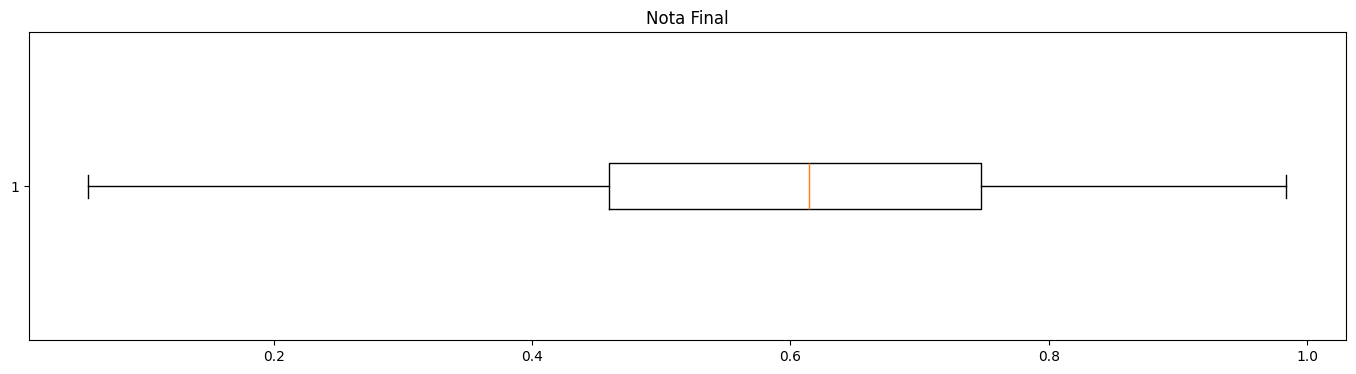

In [ ]:
plt.figure(figsize=(17, 4))
plt.boxplot(dev_df["nota_final"], vert=False)
plt.title("Nota Final")
plt.show()

## Classificação de Referência

In [ ]:
dev_df['weighted_vote_score'] = dev_df['weighted_vote_score'].astype("float32")
test_df['weighted_vote_score'] = test_df['weighted_vote_score'].astype("float32")
train_df['weighted_vote_score'] = train_df['weighted_vote_score'].astype("float32")

In [ ]:
T = 0.5

dev_df['useful'] = (dev_df['weighted_vote_score'] > T).astype(int)
test_df['useful'] = (test_df['weighted_vote_score'] > T).astype(int)
train_df['useful'] = (train_df['weighted_vote_score'] > T).astype(int)

## Calssificação Preditiva

In [ ]:
pred_T = 0.5

dev_df['predicted_useful'] = (dev_df['nota_final'] > pred_T).astype(int)
test_df['predicted_useful'] = (test_df['nota_final'] > pred_T).astype(int)
train_df['predicted_useful'] = (train_df['nota_final'] > pred_T).astype(int)

### F1 Score

In [ ]:
f1_score(test_df['useful'], test_df['predicted_useful'])

0.7990698946792505

### Matriz de Confusão

In [ ]:
tn, fp, fn, tp = confusion_matrix(
  test_df['useful'],
  test_df['predicted_useful']
).ravel()

print("TP:", tp)
print("FP:", fp)
print("FN:", fn)
print("TN:", tn)

TP: 26289
FP: 1995
FN: 11226
TN: 1081


# Exportação Arquivos Pickle dos Subconjuntos da Base

In [ ]:
dev_df.to_pickle(path_output_dev)
train_df.to_pickle(path_output_train)
test_df.to_pickle(path_output_test)